# PARTICIPANT 1

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system for external, kitchen, and living room measurements.

In [2]:
p1_eltek = ingest_aq110a(path = '../data/p1_east_london_flat/data_unprocessed/K01817-12158.csv'
                      , import_variables = ['','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
                      , column_names = ['external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc'
                                        , 'kitchen_temperature', 'kitchen_humidity', 'kitchen_co2', 'kitchen_1um', 'kitchen_25um', 'kitchen_100um', 'kitchen_airflow', 'kitchen_no2', 'kitchen_co1', 'kitchen_voc'
                                        , 'living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc']
                      , convert_no2 = True
                      , convert_co = True
                      , input_interpolate = True
                      , input_iterpolate_limit = 6
                      )

p1_eltek = p1_eltek.reset_index()

# delete external temp and rh
del p1_eltek['external_temperature']
del p1_eltek['external_humidity']


---------------------------------------------
Ingesting AQ110a data from ../data/p1_east_london_flat/data_unprocessed/K01817-12158.csv

Correction

-----------------------
32672_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32672_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32672_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32672_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32672_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32672_100um
baseline_correction

False
<class 'float'>
0.0

## Fix Eltek Data Issues

Address known sensor issues:
- CO, NO2, and PM issues in living room after 2019-06-13
- NO2 issues in all locations
- VOC issues in living room
- Humidity calibration issue (10x error)

In [3]:
# issue with co, no2, and pm in living room
# ignore all data after 12 on 13/06/2019
tempdropmask = p1_eltek['date'] >= '2019-06-13 12:00:00'
p1_eltek.loc[tempdropmask, 'living_co1'] = np.nan
# p1_eltek.loc[tempdropmask, 'living_no2'] = np.nan
p1_eltek.loc[tempdropmask, 'living_1um'] = np.nan
p1_eltek.loc[tempdropmask, 'living_25um'] = np.nan
p1_eltek.loc[tempdropmask, 'living_100um'] = np.nan

# issue no2 in living and kitchen
p1_eltek['kitchen_no2'] = np.nan
p1_eltek['living_no2'] = np.nan
p1_eltek['external_no2'] = np.nan

# issue voc in living and kitchen
# p1_eltek['kitchen_voc'] = np.nan
p1_eltek['living_voc'] = np.nan
# p1_eltek['external_voc'] = np.nan

# fixing humidity issue where sensor reading is 10x less between two dates
for col in p1_eltek.columns:
    if 'humidity' in col:
        print(col)
        mask = (p1_eltek['date'] >= '2019-10-30 16:00:00') & (p1_eltek['date'] <= '2019-11-29 17:40:00')
        p1_eltek.loc[mask, col] = p1_eltek.loc[mask, col] * 10

# baseline co1 and no2
aq110a_no2_co1_baseline(input_dataframe=p1_eltek, input_percentile=5)

# plot_grouped_variables(p1_eltek)

kitchen_humidity
living_humidity
Baseline variable = external_no2 — all-NaN column, skipping baseline correction
Baseline variable = external_co1 5th percentile = 0.0
Baseline variable = kitchen_no2 — all-NaN column, skipping baseline correction
Baseline variable = kitchen_co1 5th percentile = 349.26
Baseline variable = living_no2 — all-NaN column, skipping baseline correction
Baseline variable = living_co1 5th percentile = 302.692


## Load Bathroom Temperature, Humidity and Light Data

In [4]:
p1_bathroom_ieq = ingest_u12_012("../data/p1_east_london_flat/data_unprocessed/200122_EI130514.csv"
                              , 0
                              , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity']
                              , '5min'
                              , True
                              , index_as_date=False
                              , instrument_ref='EI130514'
                              )

p1_bathroom_light = ingest_u12_012("../data/p1_east_london_flat/data_unprocessed/200122_EI130488.csv"
                                , 0
                                , ['date', 'time', 'bathroom_light']
                                , '5min'
                                , True
                                , index_as_date=False
                                , instrument_ref='EI130488'
                                )


---------------------------------------------
Ingesting U12-012 data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130514.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 date                    0
bathroom_temperature    0
bathroom_humidity       0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130488.csv
Missing data = 
 date              0
bathroom_light    0
dtype: int64
U12-012 data ingested
---------------------------------------------



## Load Bedroom CO2 Data

In [5]:
p1_bedroom_co2 = ingest_mx1102("../data/p1_east_london_flat/data_unprocessed/200122_EI130720.csv"
                            , 1
                            , ['date', 'time', 'bedroom_temperature', 'bedroom_humidity', 'bedroom_co2']
                            , '5min'
                            , True
                            , instrument_ref='EI130720'
                            , index_as_date=False
                            )


---------------------------------------------
Ingesting MX1102 data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130720.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 date                   0
bedroom_temperature    0
bedroom_humidity       0
bedroom_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------



## Merge Eltek, Bedroom, Bathroom and Event Data

In [6]:

p1_dfs = [p1_eltek, p1_bedroom_co2, p1_bathroom_ieq, p1_bathroom_light]
p1 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p1_dfs)
p1 = p1.sort_index()

# clean-up
del p1_dfs
del p1_eltek
del p1_bedroom_co2
del p1_bathroom_ieq
del p1_bathroom_light

p1.isna().sum() # should equal 0
p1.duplicated()

p1 = p1.sort_values(by=['date'])
p1 = p1.reset_index(drop=True)

# set date as index
p1 = p1.set_index(p1['date'])
del p1['date']

# plot_grouped_variables(p1)

## Filter DataFrame Based on Campaign Dates

In [7]:

monitoring_start_date = '2019-05-02 00:00:00'
monitoring_end_date = '2020-01-20 00:00:00'

p1 = p1.loc[monitoring_start_date : monitoring_end_date]

## Get CO2 Column List

In [8]:
p1_co2_col_list = co2_col_list(p1)

## CO2 Calibration of Bedroom HOBO CO2 Loggers

Calibrate indoor CO2 sensors using outdoor reference values during unoccupied periods.

In [9]:

co2_correction_unoccupied(input_dataframe = p1
                          , input_start_and_end_as_df = True
                          , input_start_date = ''
                          , input_end_date = ''
                          , input_list_unoccupied_periods = ['2019-05-24 00:00:00', '2019-05-27 12:00:00'
                                                             , '2019-06-15 00:00:00', '2019-06-18 12:00:00'
                                                             , '2019-06-29 00:00:00', '2019-07-01 12:00:00'
                                                             , '2019-07-27 00:00:00', '2019-07-28 18:00:00'
                                                             , '2019-09-02 00:00:00', '2019-09-09 00:00:00'
                                                             , '2019-12-23 12:00:00', '2019-12-25 12:00:00']
                          , input_outdoor_co2_col = 'external_co2'
                          , input_co2_cols_to_correct = ['kitchen_co2', 'living_co2', 'bedroom_co2']
                          , input_percentile_indoor = 10
                          , input_percentile_outdoor = 50
                          )

# plot_grouped_variables(p1)


====    Start of CO2 correction    ====


Using beginning and end dates from input df
Start date =  2019-05-02 00:00:00
End date =  2020-01-20 00:00:00

-------------------------------------------------------------
----     Correcting:  kitchen_co2     ----
-------------------------------------------------------------

Loop 1
Start of unoccupied period 1 = 2019-05-24 00:00:00
End of unoccupied period 1 = 2019-05-27 12:00:00
Mid point = 2019-05-25 18:00:00
Indoor CO2 10 th percentile is  368.0
Outdoor CO2 50 th percentile is  384.0
Difference in CO2 10 th percentiles is  -16.0

Loop 2
Start of unoccupied period 2 = 2019-06-15 00:00:00
End of unoccupied period 2 = 2019-06-18 12:00:00
Mid point = 2019-06-16 18:00:00
Length between previous mid and this mid 6337
Indoor CO2 10 th percentile is  363.0
Outdoor CO2 50 th percentile is  395.0
Difference in CO2 10 th percentiles is  -32.0
Offset difference =  -16.0
Slope =  -0.002524854031876282

Loop 3
Start of unoccupied period 3 = 2019-06-29

## Import Event Data

Load window and door event data from UX90-001M sensors.

In [10]:
p1_event_dict = ingest_ux90_001m_group_new(input_file_list=
                           ['../data/p1_east_london_flat/data_unprocessed/200122_EI130831.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130833.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130832.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130835.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130818.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130836.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI130834.csv'
                            , '../data/p1_east_london_flat/data_unprocessed/200122_EI______.csv'
                           ]
                       , input_output_name_list=
                           ['main_door_event'
                            , 'bathroom_door_event'
                            , 'bedroom_door_event'
                            , 'bedroom_window_event'
                            , 'living_door_event'
                            , 'living_window_event'
                            , 'balcony_door_event'
                            , 'cooker_hood_event'
                            ]
                       , input_skiprows=0
                       , input_main_dataframe=p1
                       )

event_durations(input_event_dict=p1_event_dict)
p1_event_dict['main_door_event'] = p1_event_dict['main_door_event'].set_index(p1_event_dict['main_door_event']['date'])

# list of all events
p1_event_list = event_list_function(input_event_dict=p1_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130831.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130833.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130832.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130835.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130818.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130836.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p1_east_london_flat/data_unprocessed/200122_EI130834.csv

-----

## Import Weather Data

Load external weather data from CEDA.

In [11]:

p1_weather = ingest_ceda_weather_data(input_path = '../data/p1_east_london_flat/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' alt_pres', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_alt_pres', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p1_east_london_flat/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction    1824
external_wind_speed           7
external_temperature          2
external_dewpoint             2
external_wetb_temp            2
external_alt_pres             2
external_humidity             2
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_alt_pres          0
external_humidity          0
dtype: int64
Weather data ingested


## Merge Weather Data

In [12]:

# create a list with all p1_dfs to be merged
p1_dfs = [p1, p1_weather]
p1 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p1_dfs)
p1 = p1.sort_index()

# clean-up
del p1_dfs, p1_weather
p1.isna().sum() # should equal 0
p1.duplicated()
p1 = p1.sort_values(by=['date'])
p1 = p1.reset_index(drop=False)

# set date as index
p1 = p1.set_index(p1['date'])
del p1['date']

# plot_grouped_variables(p1)

## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones.

In [13]:

# import csv with rpi data within
p1_noise_combined = pd.read_csv("../data/p1_east_london_flat/data_unprocessed/pi_noise.csv")
p1_noise_combined['date'] = pd.to_datetime(p1_noise_combined['date'])
p1_noise_combined = p1_noise_combined.set_index(p1_noise_combined['date'])
del p1_noise_combined['date']

## Calculate A-Weighted Noise Levels

Apply A-weighting adjustments to each frequency band.

In [14]:
# calculate a-weighted average noise levels for each frequency
p1_noise_combined_temp = p1_noise_combined.copy()
# p1_noise_combined['10hz'] = p1_noise_combined['10hz']-(70.4)
# p1_noise_combined['12.5hz'] = p1_noise_combined['12.5hz']-(63.4)
# p1_noise_combined['16hz'] = p1_noise_combined['16hz']-(56.7)
p1_noise_combined_temp['20hz'] = p1_noise_combined_temp['20hz']-(50.5)
p1_noise_combined_temp['25hz'] = p1_noise_combined_temp['25hz']-(44.7)
p1_noise_combined_temp['31.5hz'] = p1_noise_combined_temp['31.5hz']-(39.4)
p1_noise_combined_temp['40hz'] = p1_noise_combined_temp['40hz']-(34.6)
p1_noise_combined_temp['50hz'] = p1_noise_combined_temp['50hz']-(30.2)
p1_noise_combined_temp['63hz'] = p1_noise_combined_temp['63hz']-(26.2)
p1_noise_combined_temp['80hz'] = p1_noise_combined_temp['80hz']-(22.5)
p1_noise_combined_temp['100hz'] = p1_noise_combined_temp['100hz']-(19.1)
p1_noise_combined_temp['125hz'] = p1_noise_combined_temp['125hz']-(16.1)
p1_noise_combined_temp['160hz'] = p1_noise_combined_temp['160hz']-(13.4)
p1_noise_combined_temp['200hz'] = p1_noise_combined_temp['200hz']-(10.9)
p1_noise_combined_temp['250hz'] = p1_noise_combined_temp['250hz']-(8.6)
p1_noise_combined_temp['315hz'] = p1_noise_combined_temp['315hz']-(6.6)
p1_noise_combined_temp['400hz'] = p1_noise_combined_temp['400hz']-(4.8)
p1_noise_combined_temp['500hz'] = p1_noise_combined_temp['500hz']-(3.2)
p1_noise_combined_temp['630hz'] = p1_noise_combined_temp['630hz']-(1.9)
p1_noise_combined_temp['800hz'] = p1_noise_combined_temp['800hz']-(0.8)
p1_noise_combined_temp['1000hz'] = p1_noise_combined_temp['1000hz']
p1_noise_combined_temp['1250hz'] = p1_noise_combined_temp['1250hz']+(0.6)
p1_noise_combined_temp['1600hz'] = p1_noise_combined_temp['1600hz']+(1.0)
p1_noise_combined_temp['2000hz'] = p1_noise_combined_temp['2000hz']+(1.2)
p1_noise_combined_temp['2500hz'] = p1_noise_combined_temp['2500hz']+(1.3)
p1_noise_combined_temp['3150hz'] = p1_noise_combined_temp['3150hz']+(1.2)
p1_noise_combined_temp['4000hz'] = p1_noise_combined_temp['4000hz']+(1.0)
p1_noise_combined_temp['5000hz'] = p1_noise_combined_temp['5000hz']+(0.6)
p1_noise_combined_temp['6300hz'] = p1_noise_combined_temp['6300hz']-(0.1)
p1_noise_combined_temp['8000hz'] = p1_noise_combined_temp['8000hz']-(1.1)
p1_noise_combined_temp['10000hz'] = p1_noise_combined_temp['10000hz']-(2.5)
# p1_noise_combined['12500hz'] = p1_noise_combined['12500hz']-(4.3)
# p1_noise_combined['16000hz'] = p1_noise_combined['16000hz']-(6.6)
# p1_noise_combined['20000hz'] = p1_noise_combined['20000hz']-(9.3)

# create list with all cols and remove microphone
p1_noise_combined_temp_cols = list(p1_noise_combined_temp.columns)
p1_noise_combined_temp_cols.remove('microphone')

p1_noise_combined['dba'] = sum_sound_calculation_df(input_df=p1_noise_combined_temp
                                                 , input_col_list=p1_noise_combined_temp_cols
                                                 )

del p1_noise_combined_temp, p1_noise_combined_temp_cols

/opt/anaconda3/envs/phd/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Process Indoor and Outdoor Noise Data

Separate indoor and outdoor measurements, then calculate 5-minute averages.

In [15]:
# how to calculate the average:
# take each value, divide by 10 and anti-log.
# add all values together, log the result and multiply by 10 for final db(a) value.

# filter for noise inside and noise outside
p1_noise_inside = p1_noise_combined[(p1_noise_combined['microphone'] == 'I')]
p1_noise_outside = p1_noise_combined[(p1_noise_combined['microphone'] == 'O')]
del p1_noise_inside['microphone'], p1_noise_outside['microphone']

cols = list(p1_noise_inside.columns)

# indoor noise
for columns in cols:
    p1_noise_inside.loc[:, columns] = 10 ** (p1_noise_inside[columns] / 10)

p1_noise_inside = p1_noise_inside.resample('5min').sum()
for columns in cols:
    p1_noise_inside[columns] = 10*(np.log10(p1_noise_inside[columns]/5))

# outdoor noise
for columns in cols:
    p1_noise_outside.loc[:, columns] = 10 ** (p1_noise_outside[columns] / 10)
p1_noise_outside = p1_noise_outside.resample('5min').sum()
for columns in cols:
    p1_noise_outside[columns] = 10*(np.log10(p1_noise_outside[columns]/5))

/opt/anaconda3/envs/phd/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Calculate Noise Differences and Clean Data

In [16]:
# calculate differences
p1_noise_differences = pd.DataFrame()

for freq in cols:
    p1_noise_differences[freq] = p1_noise_outside[freq] - p1_noise_inside[freq]

p1_noise_differences = p1_noise_differences.add_prefix('difference_')

p1_combined_noise = p1_noise_differences
del cols, columns, freq, p1_noise_differences, p1_noise_combined
p1_noise_inside = p1_noise_inside.add_prefix('inside_')
p1_noise_outside = p1_noise_outside.add_prefix('outside_')

# handling infinite and nan values
print('Changing inf to NaNs and interpolating noise data')
for loop_dataframe in [p1_noise_inside, p1_noise_outside]:
    loop_dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)
    loop_dataframe.interpolate(method='linear', limit=4, limit_direction='forward', inplace=True)
    loop_dataframe.fillna(0, inplace=True)

Changing inf to NaNs and interpolating noise data


## Merge Noise Data into Main DataFrame

In [17]:

# create a list with all p1_dfs to be merged
p1_dfs = [p1, p1_noise_inside, p1_noise_outside, p1_combined_noise]
# merge
p1 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p1_dfs)
# sort by index
p1 = p1.sort_index()

# clean-up
del p1_dfs
del p1_noise_inside, p1_noise_outside, p1_combined_noise
# p1.isna().sum() # should equal 0
# p1.duplicated()
p1 = p1.sort_values(by=['date'])
p1 = p1.reset_index(drop=False)

# set date as index
p1 = p1.set_index(p1['date'])
del p1['date']

# plot_grouped_variables(p1)

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [18]:
p1_variable_list = ['temperature',
                 'humidity',
                 'abshumid',
                 'co2',
                 '1um',
                 '25um',
                 '100um',
                 'airflow',
                 'no2',
                 'co1',
                 'voc',
                 'light'
                 ]

p1_rooms_and_variables = rooms_variables_dict(input_dataframe=p1,
                                           variables=p1_variable_list)

# manually add noise to living room
# inside_dba
# p1_rooms_and_variables['living'].append('inside_dba')
p1_rooms_and_variables['living'].append('dba')
p1_rooms_and_variables['external'].append('dba')

p1['living_dba'] = p1['inside_dba']
p1['external_dba'] = p1['outside_dba']

bedroom







['temperature', 'humidity', 'co2']
bathroom







['temperature', 'humidity', 'light']
external







['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'alt_pres', 'humidity']
living







['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
kitchen







['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']


## Create Room and Event Dictionary

In [19]:
p1_rooms_list = ['living', 'kitchen', 'bathroom', 'bedroom']
p1_living_events = ['living_door_event', 'living_window_event', 'balcony_door_event', 'cooker_hood_event']
p1_kitchen_events = ['living_door_event', 'living_window_event', 'balcony_door_event', 'cooker_hood_event']
p1_bathroom_events = ['bathroom_door_event']
p1_bedroom_events = ['bedroom_door_event', 'bedroom_window_event']
p1_rooms_and_events = {}
p1_rooms_and_events['living'] = p1_living_events
p1_rooms_and_events['kitchen'] = p1_kitchen_events
p1_rooms_and_events['bathroom'] = p1_bathroom_events
p1_rooms_and_events['bedroom'] = p1_bedroom_events
del p1_bathroom_events, p1_bedroom_events, p1_kitchen_events, p1_living_events

## Final Data Filtering and Interpolation

Apply final date filters, interpolate missing values, and check for data quality issues.

In [20]:

p1 = p1.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p1_event_dict:
    p1_event_dict[loop_df] = p1_event_dict[loop_df][(p1_event_dict[loop_df]['date'] > monitoring_start_date) & (p1_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables
for loop_room in p1_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p1_rooms_and_variables[loop_room]:
        print(loop_room + '_' + loop_variable)
        print('--- Before ---')
        print('NaNs = ', p1[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p1[loop_room + '_' + loop_variable]) - np.isfinite(p1[loop_room + '_' + loop_variable]).sum()) # count all infinite values
        print('--- After ---')
        p1[loop_room + '_' + loop_variable] = p1[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
        print('NaNs = ', p1[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p1[loop_room + '_' + loop_variable]) - np.isfinite(p1[loop_room + '_' + loop_variable]).sum()) # count all infinite


bedroom
bedroom_temperature
--- Before ---
NaNs =  3122
inf =  3122
--- After ---
NaNs =  3118
inf =  3118
bedroom_humidity
--- Before ---
NaNs =  3122
inf =  3122
--- After ---
NaNs =  3118
inf =  3118
bedroom_co2
--- Before ---
NaNs =  3122
inf =  3122
--- After ---
NaNs =  3118
inf =  3118

bathroom
bathroom_temperature
--- Before ---
NaNs =  54044
inf =  54044
--- After ---
NaNs =  54040
inf =  54040
bathroom_humidity
--- Before ---
NaNs =  54044
inf =  54044
--- After ---
NaNs =  54040
inf =  54040
bathroom_light
--- Before ---
NaNs =  32356
inf =  32356
--- After ---
NaNs =  32352
inf =  32352

external
external_co2
--- Before ---
NaNs =  4045
inf =  4045
--- After ---
NaNs =  4019
inf =  4019
external_1um
--- Before ---
NaNs =  9329
inf =  9329
--- After ---
NaNs =  8821
inf =  8821
external_25um
--- Before ---
NaNs =  9329
inf =  9329
--- After ---
NaNs =  8821
inf =  8821
external_100um
--- Before ---
NaNs =  9329
inf =  9329
--- After ---
NaNs =  8821
inf =  8821
external_ai

## Plot Results

Generate plots of all grouped variables.

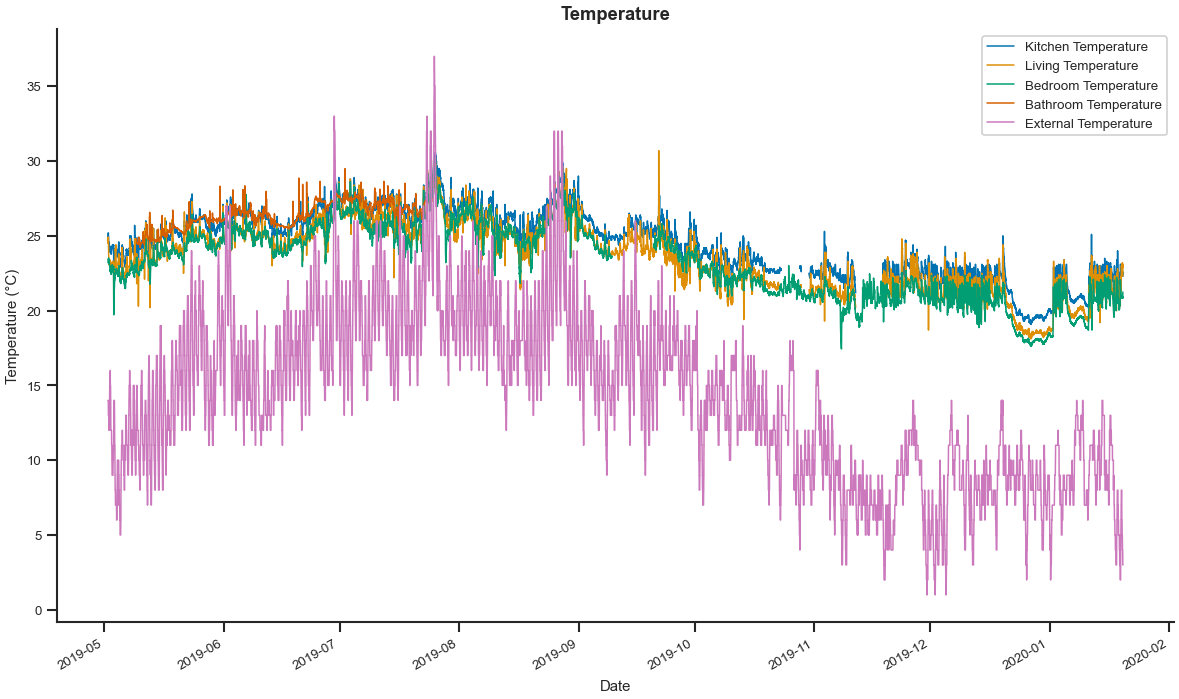

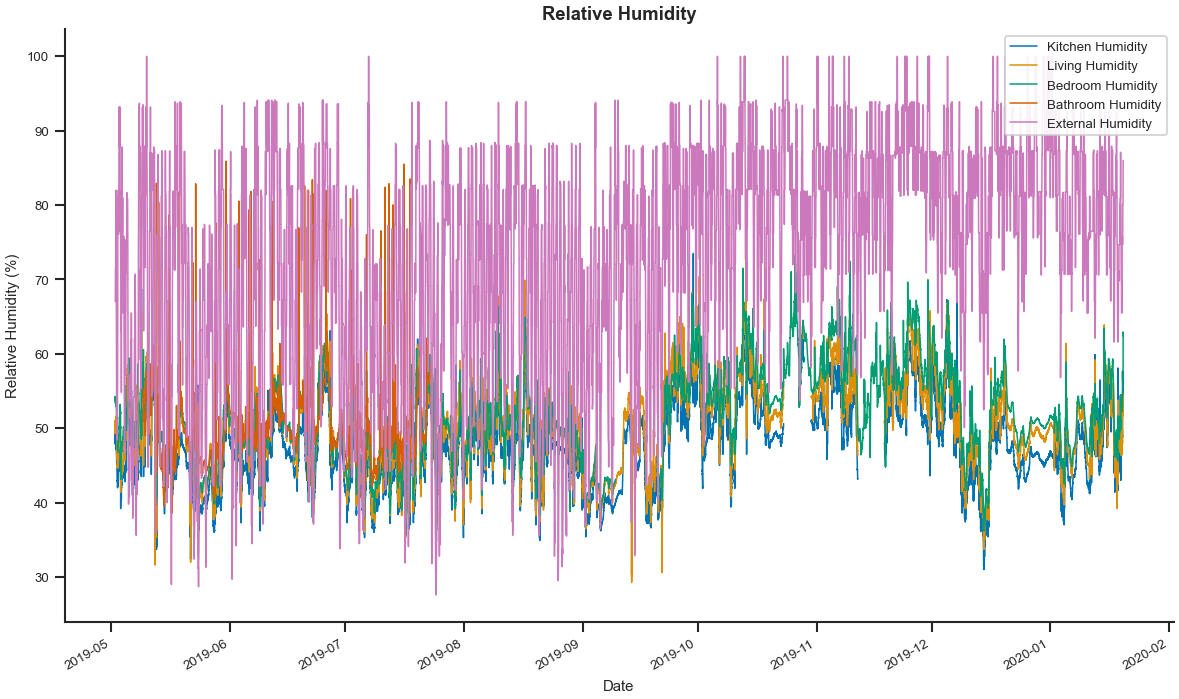

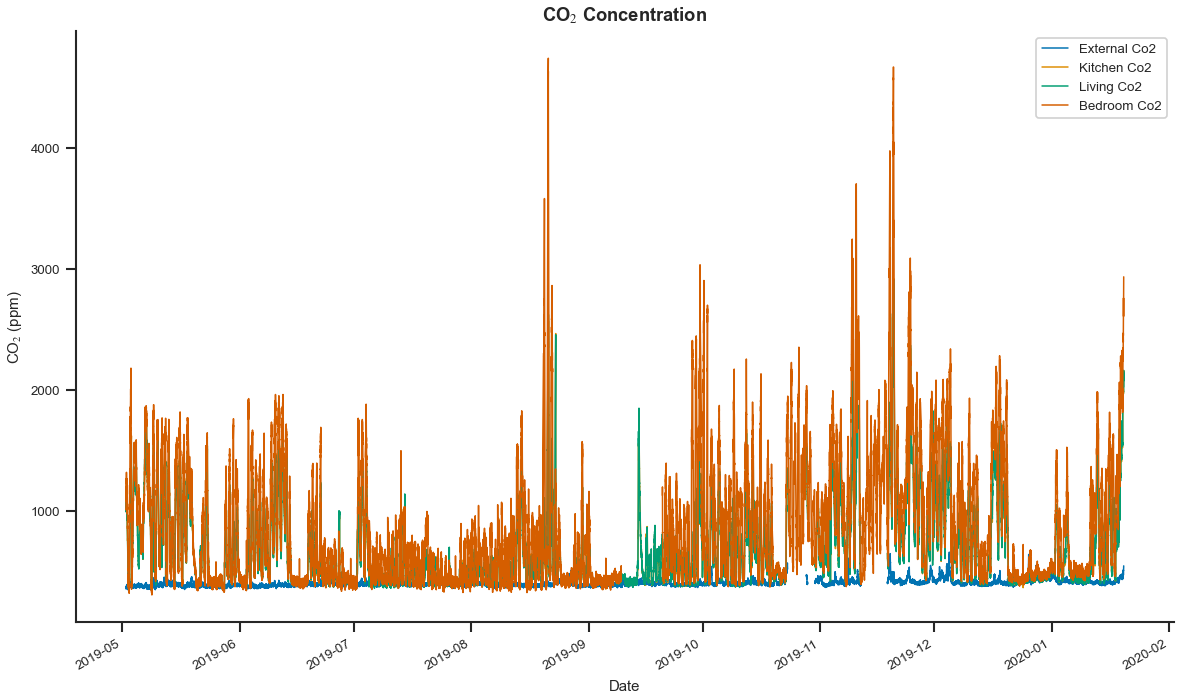

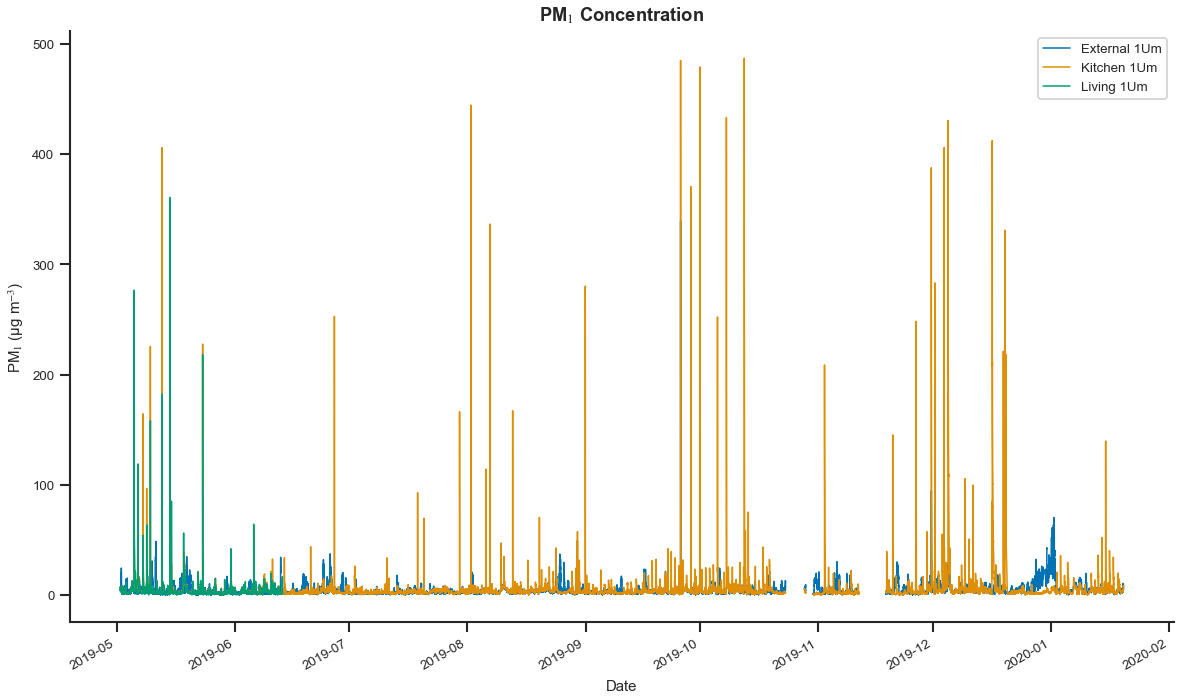

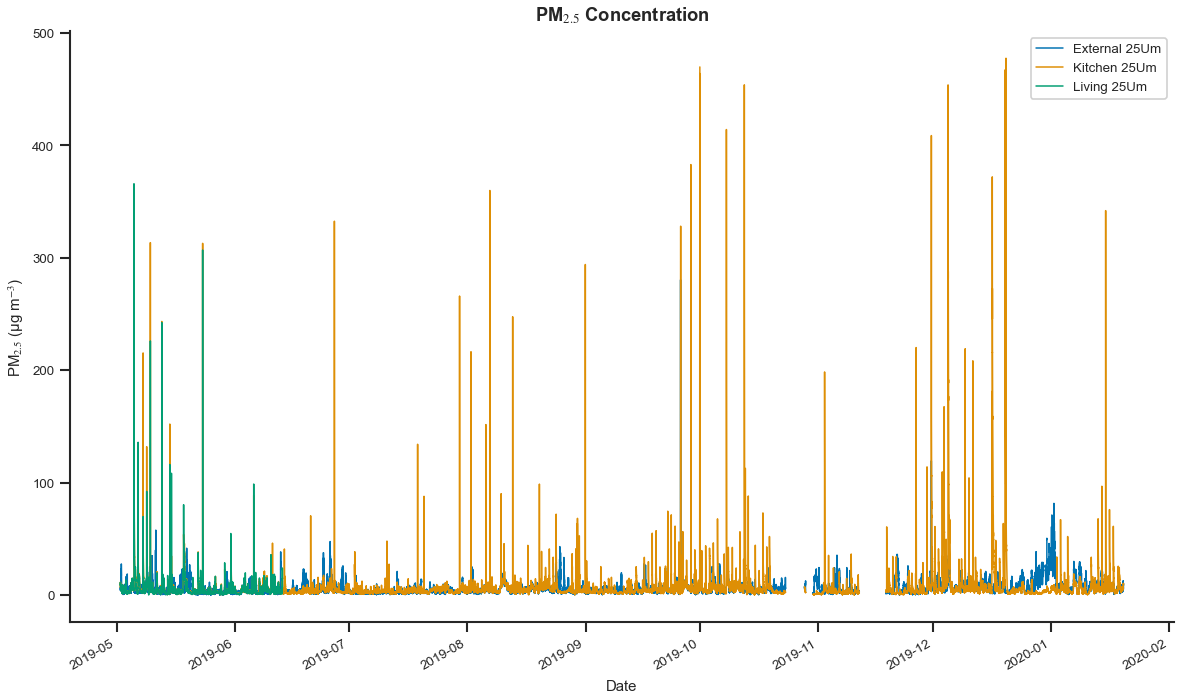

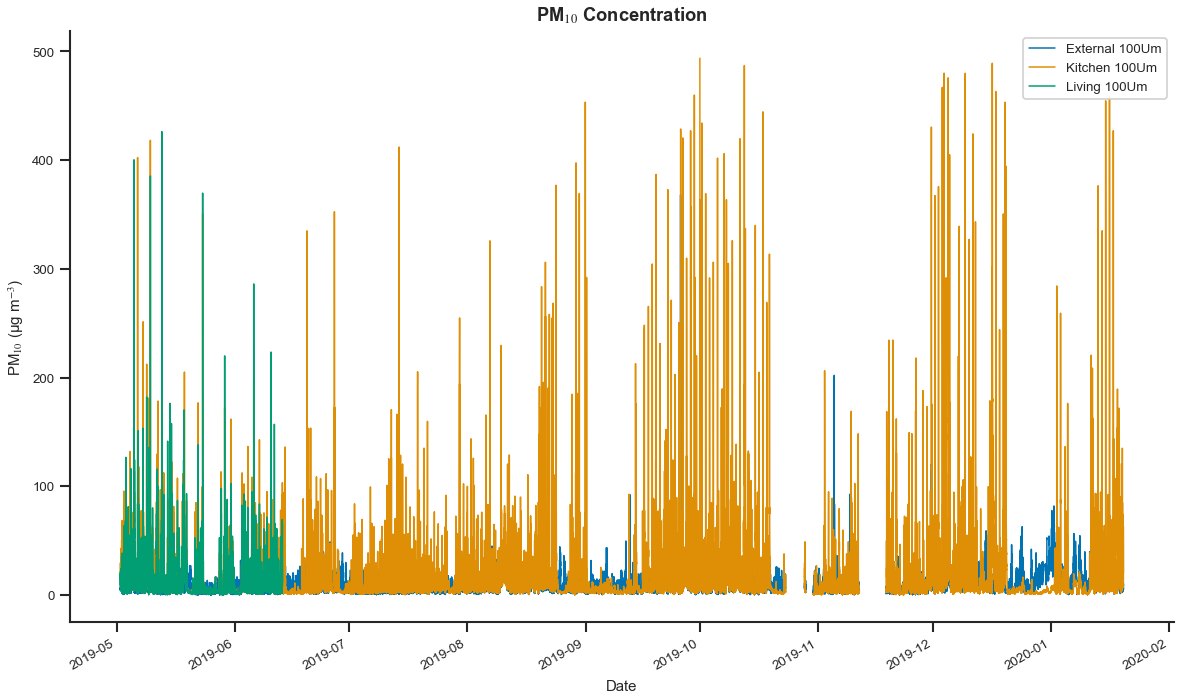

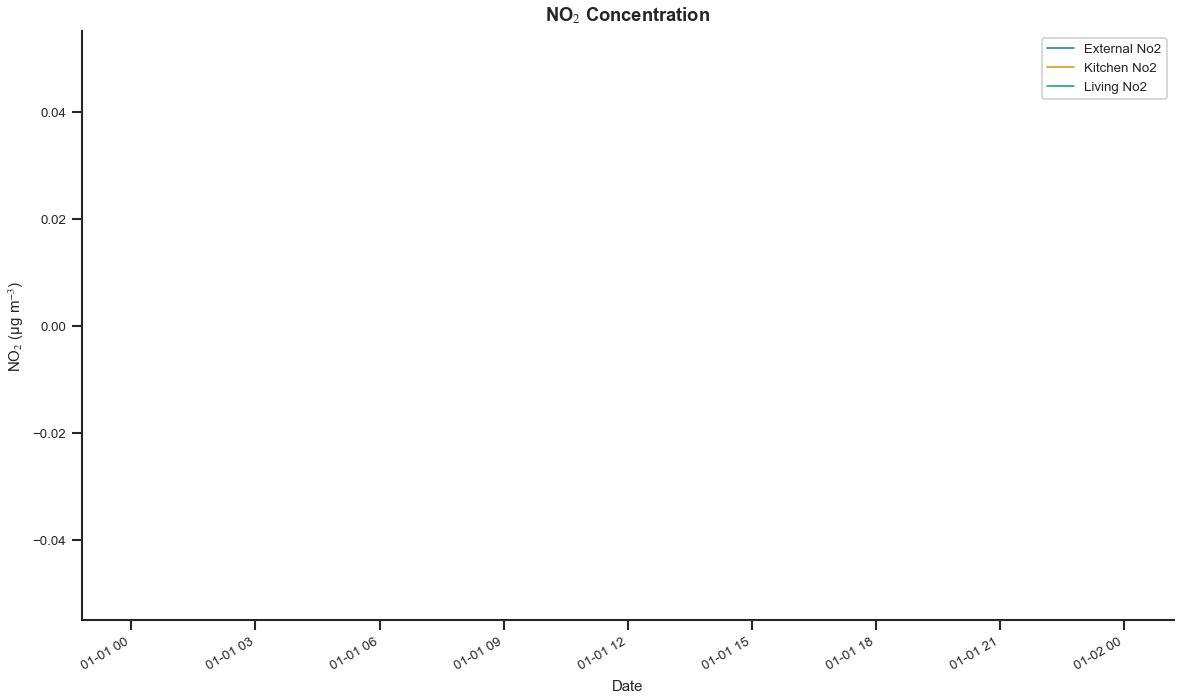

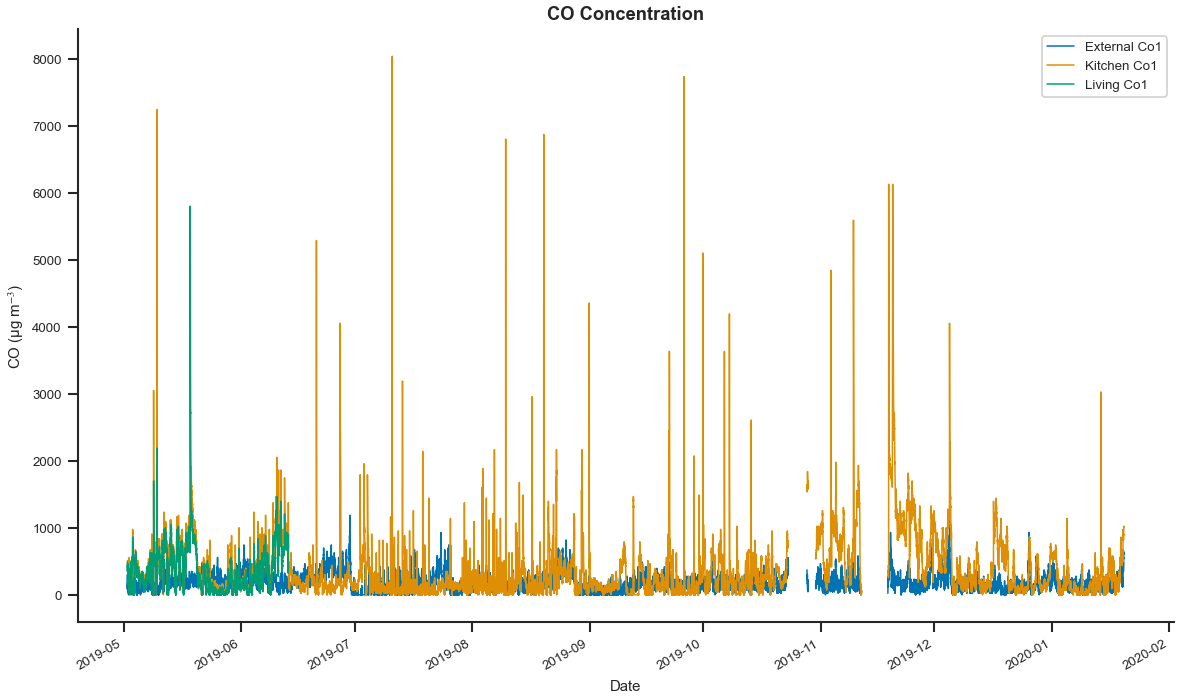

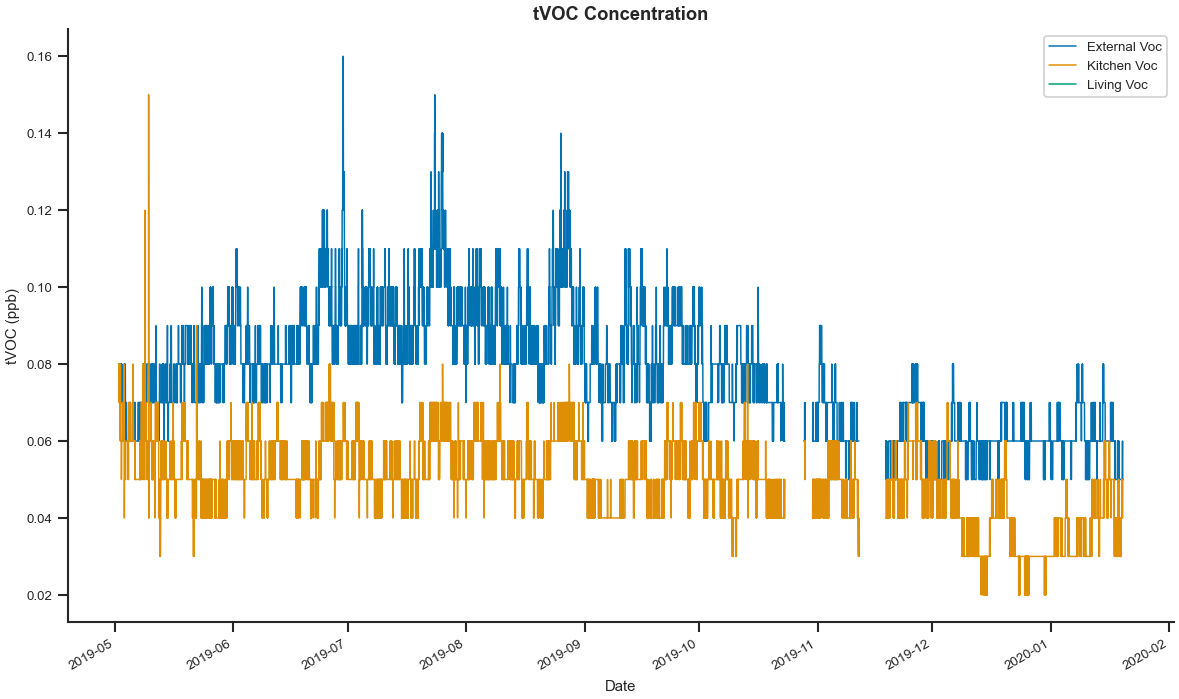

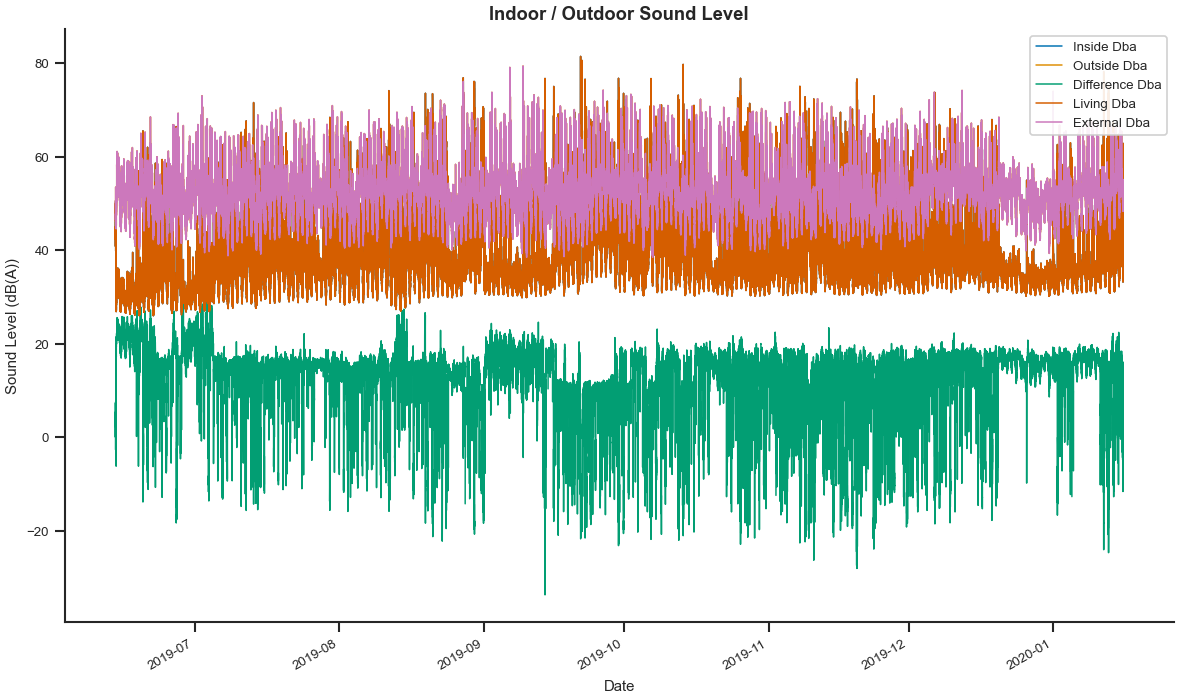

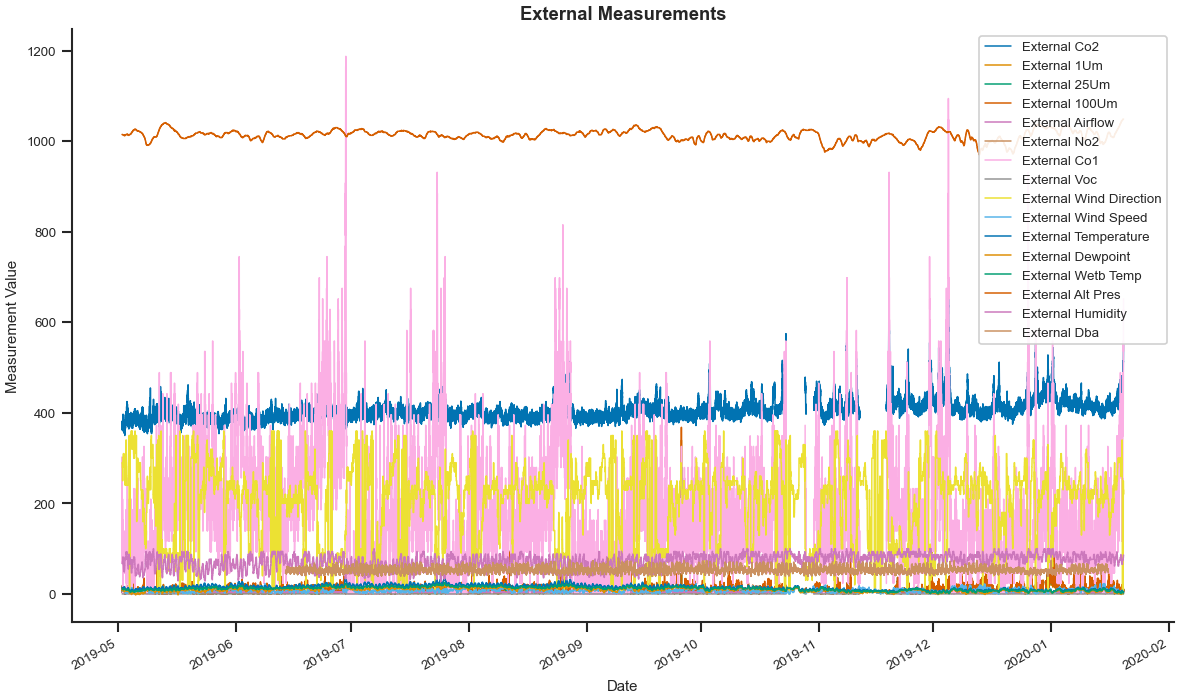

In [21]:
plot_grouped_variables(input_dataframe=p1, input_save=True, save_path="../data/p1_east_london_flat/plots/", figsize=(10, 6), dpi=300)


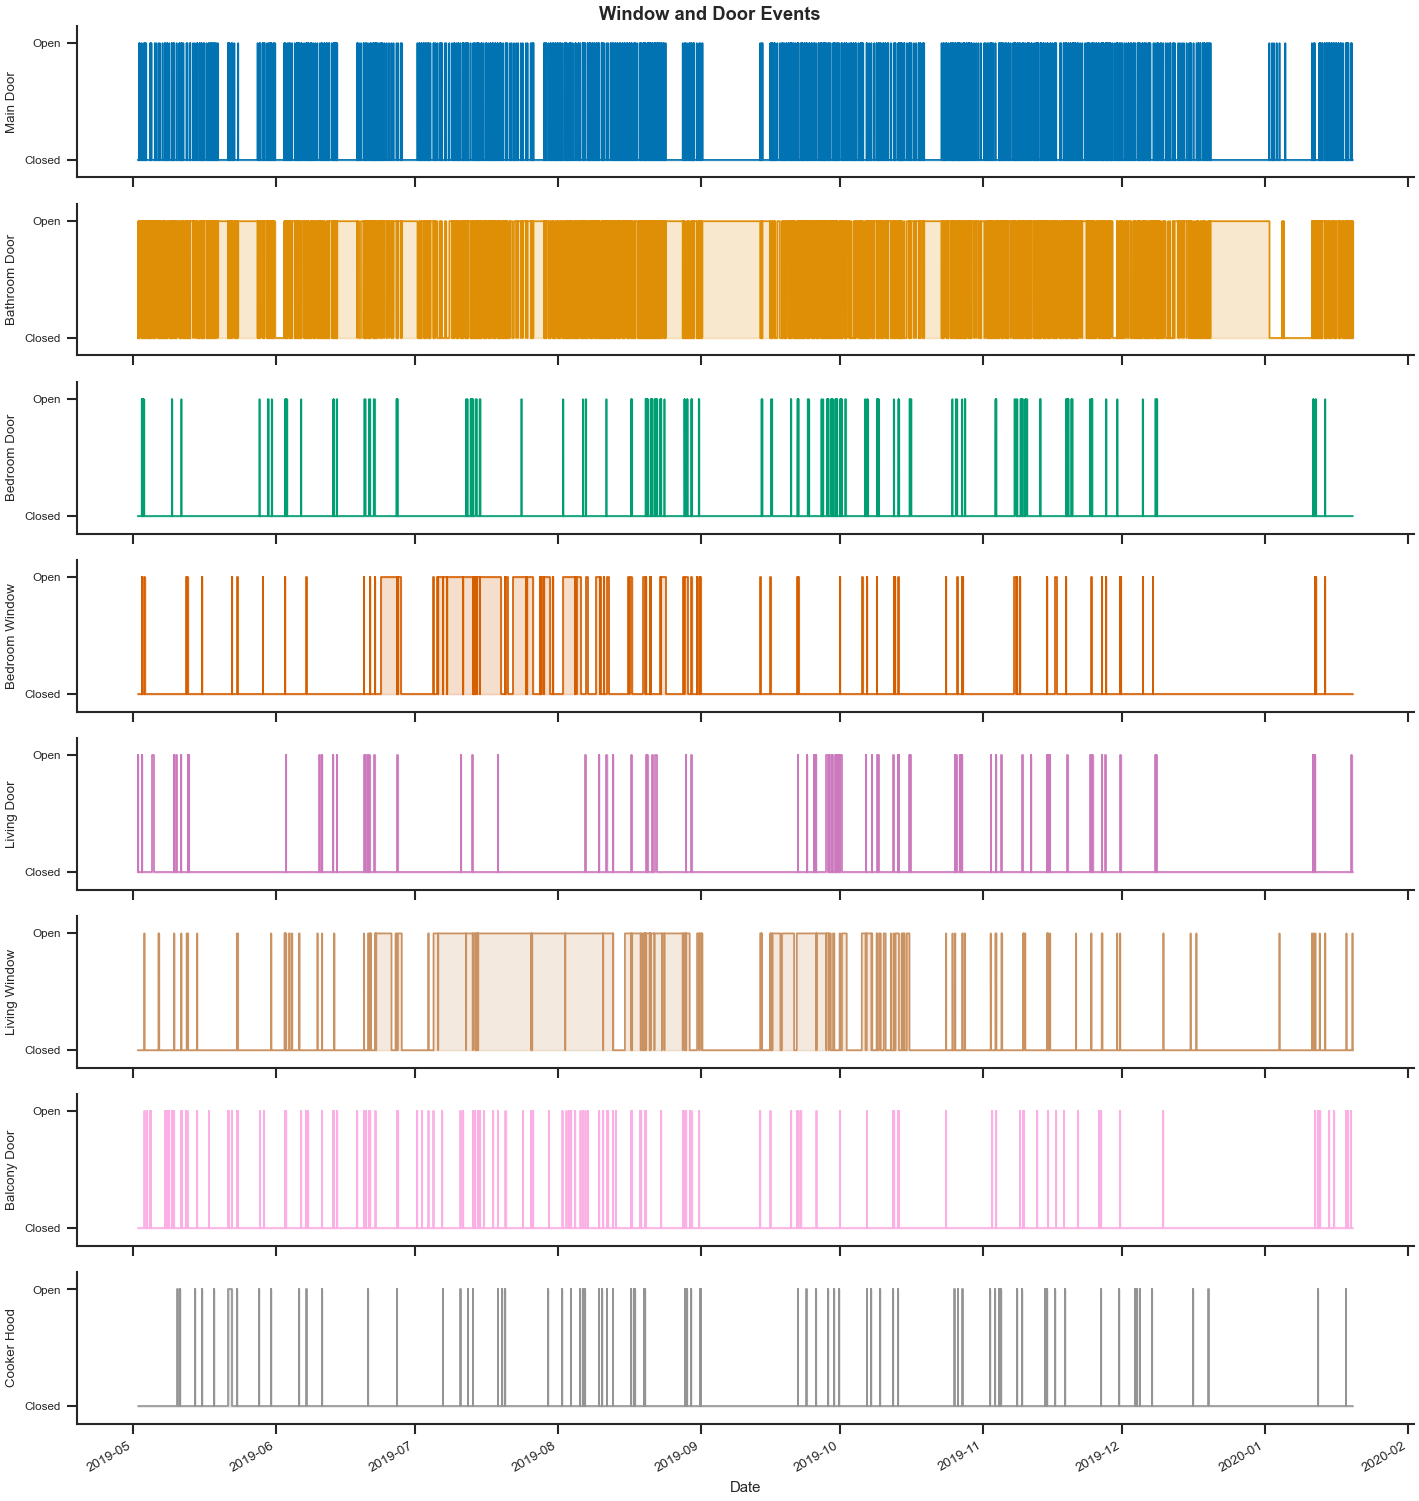

In [22]:
plot_event_timeseries(input_event_dict=p1_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p1_east_london_flat/plots/')

## Summary statistics

In [23]:
p1_continuous_stats, p1_event_stats = summary_statistics(
    input_dataframe=p1,
    input_rooms_and_variables=p1_rooms_and_variables,
    input_event_dict=p1_event_dict,
    input_rooms_and_events=p1_rooms_and_events
)

# Print the number of days of data collected
num_days = (p1.index[-1] - p1.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  bedroom_temperature: n=72627, n_missing=3118, mean=23.171, median=23.472
  bedroom_humidity: n=72627, n_missing=3118, mean=51.795, median=51.221
  bedroom_co2: n=72627, n_missing=3118, mean=858.234, median=667.0
  bathroom_temperature: n=21705, n_missing=54040, mean=26.358, median=26.378
  bathroom_humidity: n=21705, n_missing=54040, mean=49.963, median=49.395
  bathroom_light: n=43393, n_missing=32352, mean=86.624, median=11.8
  external_co2: n=71726, n_missing=4019, mean=407.769, median=402.0
  external_1um: n=66924, n_missing=8821, mean=3.785, median=2.6
  external_25um: n=66924, n_missing=8821, mean=5.302, median=3.76
  external_100um: n=66924, n_missing=8821, mean=7.053, median=4.92
  external_airflow: n=71726, n_missing=4019, mean=3.503, median=3.68
  external_no2: n=0, n_missing=75745, mean=nan, median=nan
  external_co1: n=71726, n_missing=4019, mean=164.943, median=139.704
  external_voc: n=71726, n_missing=4

## Save outputs

In [24]:
save_participant_outputs(
    n=1,
    df=p1,
    event_dict=p1_event_dict,
    rooms_and_variables=p1_rooms_and_variables,
    rooms_and_events=p1_rooms_and_events,
    rooms_list=p1_rooms_list,
    continuous_stats=p1_continuous_stats,
    event_stats=p1_event_stats,
    data_dir='../data/p1_east_london_flat')

p1 outputs saved to ../data/p1_east_london_flat/data_processed/p1_outputs.pkl
